In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [6]:
#банально скопипастил из прошлого 
P = np.array([
    [0.332275, 0.154930, 0.224743, 0.288052],
    [0.343810, 0.233673, 0.044756, 0.377761],
    [0.280076, 0.192421, 0.228673, 0.298830],
    [0.228771, 0.171491, 0.226221, 0.373517]
], dtype=float)

alphabet = ['A', 'C', 'G', 'T']

In [7]:
# 1. Стационарное распределение pi из уравнения pi = pi P
eigvals, eigvecs = np.linalg.eig(P.T)
k_stat = np.argmin(np.abs(eigvals - 1))
pi = np.real(eigvecs[:, k_stat])
pi = pi / pi.sum()

print("Stationary distribution pi:")
for b, val in zip(alphabet, pi):
    print(f"{b}: {val:.6f}")

Stationary distribution pi:
A: 0.289604
C: 0.182060
G: 0.193229
T: 0.335107


In [9]:
# 2. Вычисление P^k и норм ||P^k - P^(k-1)||
norms = []
powers = {}

P_prev = np.eye(P.shape[0])

for k in range(1, 1001):
    Pk = np.linalg.matrix_power(P, k)
    powers[k] = Pk

    diff_norm = np.linalg.norm(Pk - P_prev, ord='fro')
    norms.append(diff_norm)

    P_prev = Pk


In [10]:
# 3. Вывод нескольких степеней для демонстрации
for k in [1, 2, 5, 10, 50, 100, 500, 1000]:
    print(f"\nP^{k}:")
    print(pd.DataFrame(powers[k], index=alphabet, columns=alphabet))


P^1:
          A         C         G         T
A  0.332275  0.154930  0.224743  0.288052
C  0.343810  0.233673  0.044756  0.377761
G  0.280076  0.192421  0.228673  0.298830
T  0.228771  0.171491  0.226221  0.373517

P^2:
          A         C         G         T
A  0.292516  0.180326  0.198167  0.328991
C  0.293534  0.181264  0.183419  0.341782
G  0.291628  0.183604  0.191450  0.333318
T  0.283784  0.183101  0.195318  0.337797

P^5:
          A         C         G         T
A  0.289609  0.182059  0.193230  0.335102
C  0.289600  0.182061  0.193232  0.335107
G  0.289604  0.182059  0.193231  0.335106
T  0.289601  0.182061  0.193226  0.335112

P^10:
          A        C         G         T
A  0.289604  0.18206  0.193229  0.335107
C  0.289604  0.18206  0.193229  0.335107
G  0.289604  0.18206  0.193229  0.335107
T  0.289604  0.18206  0.193229  0.335107

P^50:
          A        C         G         T
A  0.289604  0.18206  0.193229  0.335107
C  0.289604  0.18206  0.193229  0.335107
G  0.28960

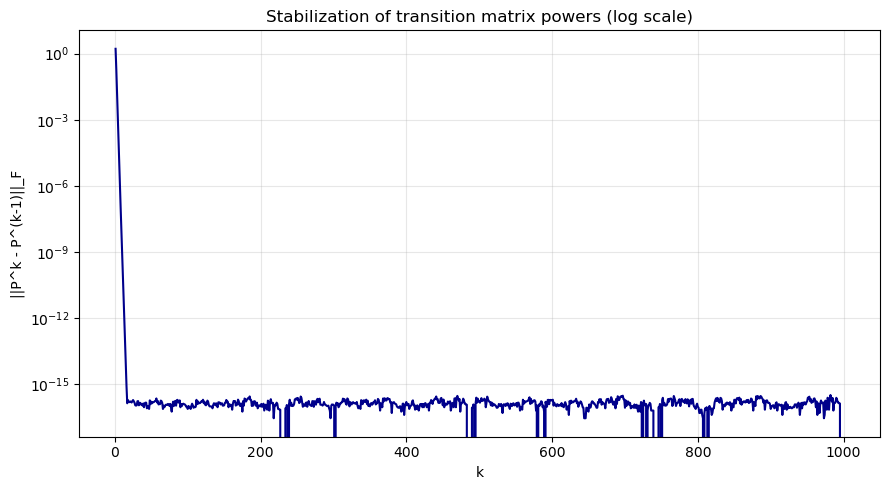

In [12]:
# 4. График стабилизации
plt.figure(figsize=(9, 5))
plt.plot(range(1, 1001), norms, color='darkblue')
plt.yscale('log')
plt.xlabel('k')
plt.ylabel(r'||P^k - P^(k-1)||_F')
plt.title('Stabilization of transition matrix powers (log scale)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
# 5. Проверка, что строки P^1000 близки друг к другу и к pi
P1000 = powers[1000]
print("\nP^1000:")
print(pd.DataFrame(P1000, index=alphabet, columns=alphabet))

print("\nRows of P^1000:")
for i, row in enumerate(P1000):
    print(f"{alphabet[i]} row: {row}")

print("\nDifference between rows of P^1000 and pi:")
for i, row in enumerate(P1000):
    print(f"{alphabet[i]} row - pi = {row - pi}")


P^1000:
          A        C         G         T
A  0.289604  0.18206  0.193229  0.335107
C  0.289604  0.18206  0.193229  0.335107
G  0.289604  0.18206  0.193229  0.335107
T  0.289604  0.18206  0.193229  0.335107

Rows of P^1000:
A row: [0.28960378 0.18206002 0.19322924 0.33510696]
C row: [0.28960378 0.18206002 0.19322924 0.33510696]
G row: [0.28960378 0.18206002 0.19322924 0.33510696]
T row: [0.28960378 0.18206002 0.19322924 0.33510696]

Difference between rows of P^1000 and pi:
A row - pi = [-1.60982339e-15 -6.38378239e-16 -9.71445147e-16 -1.66533454e-15]
C row - pi = [-1.60982339e-15 -6.38378239e-16 -9.71445147e-16 -1.66533454e-15]
G row - pi = [-1.60982339e-15 -6.38378239e-16 -9.71445147e-16 -1.66533454e-15]
T row - pi = [-1.60982339e-15 -6.38378239e-16 -9.71445147e-16 -1.66533454e-15]


In [14]:
# 6. Можно сохранить данные в таблицу
df_norms = pd.DataFrame({
    "k": np.arange(1, 1001),
    "frobenius_norm": norms
})
df_norms.to_csv("pk_stabilization_norms.csv", index=False)
